<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week13_0526_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0526(월) 13주차 과제*\
*딥러닝 파이토치 교과서 7장 시계열 분석 - 01,02,03  p.360-371*

# 7.1 시계열 문제

**시계열 분석** \
시간에 따라 변하는 데이터를 사용하여 추이를 분석하는 것\
독립 변수를 사용하여 종속 변수를 예측하는 일반적인 머신 러닝에서, 시간을 독립 변수로 사용한다는 특징이 있음.

**시계열 형태**
- 불규칙 변동: 시계열 자료에서 시간에 따른 규칙적인 움직임과 달리 규칙성이 없어 예측 불가능하고 우연적으로 발생하는 변동.\
ex) 전쟁, 홍수, 파업 등

- 추세 변동: 시계열 자료가 갖는 장기적인 변화 추세.\
짧은 기간 동안에는 추세 변동을 찾기 어려운 단점이 있음.\
ex) 국내총생산(GDP), 인구증가율 등

- 순환 변동: 2~3년 정도의 일정한 기간을 주기로 순환적으로 나타나는 변동.\
1년 이내 주기로 곡선을 그리며 추세 변동에 따라 변동하는 것\
ex) 경기 변동

- 계절 변동: 시계열 자료에서 보통 계절적 영향과 사회적 관습에 따라 1년 주기로 발생하는 것을 의미함.\
보통 계절에 따라 순환하며 변동하는 특성이 있음.

> 결국 시계열 데이터는 규칙적 시계열(트렌드와 분산이 불변하는 데이터)과 불규칙적 시계열(트렌드 혹은 분산이 변화하는 시계열 데이터)로 나눌 수 있음.

---
---

# 7.2 AR, MA, ARMA, ARIMA

AR. MA. ARMA. ARIMA 모델 적용: 불규칙적 시계열 데이터에 규칙성을 부여하는 방법

## 7.2.1 AR 모델

**AR 모델** (자기 회귀 모델)
- 이전 관측 값이 이후 관측 값에 영향을 준다는 아이디어에 대한 모형

**AR 모델 수식**

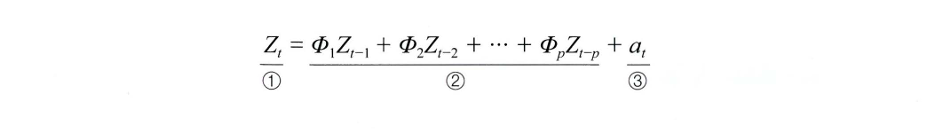

> #1: 시계열 데이터에서 현재 시점
> #2: 과거가 현재에 미치는 영향을 나타내는 모수(φ)에 시계열 데이터의 과거 시점을 곱한 것
> #3: 시계열 분석에서 오차 항(백색 잡음)

-> p 시점 이전의 데이터에 의해 현재 시점의 데이터가 영향을 받는 모형

---

## 7.2.2 MA 모델

**MA 모델** (이동 평균 모델)
- 트렌드가 변화하는 상황에 적합한 회귀 모델
- 윈도우라는 개념을 사용하는데, 시계열을 따라 윈도우 크기만큼 슬라이딩(moving)된다고 하여 이동 평균 모델이라고 함.

**MA 모델 수식**

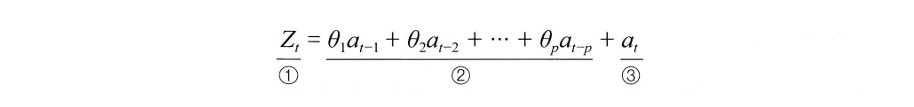

> #1: 시계열 데이터에서 현재 시점
> #2: 매개변수($\theta$)에 과거 시점의 오차를 곱한 것
> #3: 오차 항

-> 이전 데이터의 오차에서 현재 데이터의 상태를 추론하는 모델

---

## 7.2.3 ARMA 모델

**ARMA 모델** (자기 회귀 이동 평균 모델)
- AR과 MA모델을 섞은 모델
- AR, MA 두 가지 관점에서 과거의 데이터를 사용

**ARMA 모델 수식**

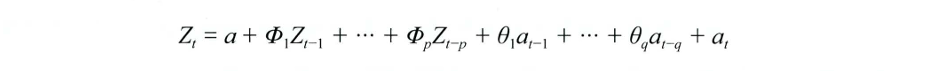

---

## 7.2.4 ARIMA 모델

**ARIMA 모델** (자기 회귀 누적 이동 평균 모델)
- 자기 회귀와 이동 평균을 둘 다 고려하는 모형
- 과거 데이터의 선형 관계 뿐만 아니라 추세까지 고려한 모델

**ARIMA 모델을 구현 절차**
1. ARIMA() 함수 호출
    - ARIMA(p,d,q)의 파라미터
        - p: 자기 회귀 치수
        - d: 차분 차수
        - q: 이동 평균 차수 (0일 때, 시계열이 정지 상태)

2. fit() 메서드 호출 -> 모델에 데이터를 적용해 훈련시킴

3. predict() 메서드 호출 -> 예측

**예제에서 ARIMA(5, 1, 0) 적용**
- ARIMA() 함수를 사용하여 간단한 오차 정보 확인

In [2]:
# statsmodel 라이브러리 설치
!pip install statsmodels

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 2278 (delta 4), reused 27 (delta 3), pack-reused 2246 (from 1)
Receiving objects: 100% (2278/2278), 330.30 MiB | 30.37 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.
/content/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog
                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Sat, 24 May 2025   AIC                            411.302
Time:                        07:09:46   BIC                            420.634
Sample:                    01-01-1991

<ipython-input-8-62c4f77538cb>:16: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0], index_col=0,
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


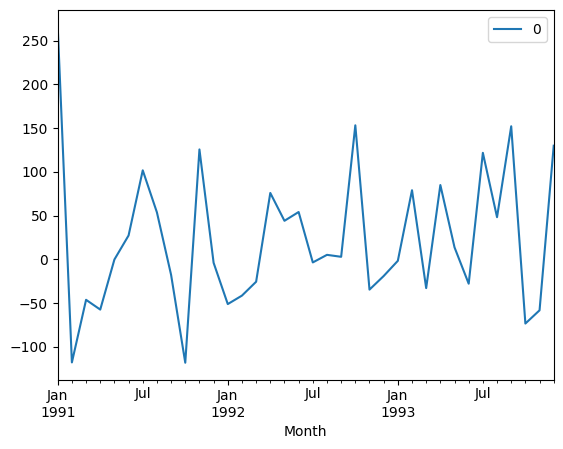

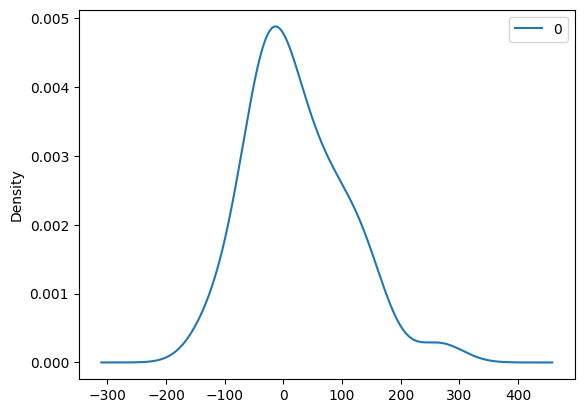

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [8]:
from datetime import datetime
# 코드 7-1 ARIMA() 함수를 호출하여 sales 데이터셋에 대한 예측

from pandas import read_csv
from pandas import DatetimeIndex
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

!git clone https://github.com/gilbutITbook/080289.git
%cd 080289/chap05/data/catanddog/

df = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0], index_col=0,
                  date_parser=parser)

series = df.iloc[:, 0]

model = ARIMA(series, order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())

residuals = DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

-> 오류 분포 결과를 보면 값이 치우쳐 있음(오류 평균(mean) 값이 0이 아님)

- ARIMA() 함수를 사용한 예측 진행

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 2278 (delta 4), reused 27 (delta 3), pack-reused 2246 (from 1)
Receiving objects: 100% (2278/2278), 330.30 MiB | 28.01 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.
/content/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog/080289/chap05/data/catanddog
predicted=352.855343, expected=346.300000


<ipython-input-11-9f3a5e03fd1c>:16: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0], index_col=0,


predicted=277.398036, expected=329.700000
predicted=368.753734, expected=445.400000
predicted=331.773635, expected=325.900000
predicted=372.070407, expected=449.300000
predicted=360.020872, expected=411.300000
predicted=454.526230, expected=417.400000
predicted=388.690699, expected=545.500000
predicted=437.632447, expected=477.600000
predicted=516.437624, expected=687.000000
predicted=520.916191, expected=435.300000
predicted=675.594647, expected=587.300000
predicted=505.201016, expected=676.900000
Test MSE: 9118.818
Test MSE: 9118.818


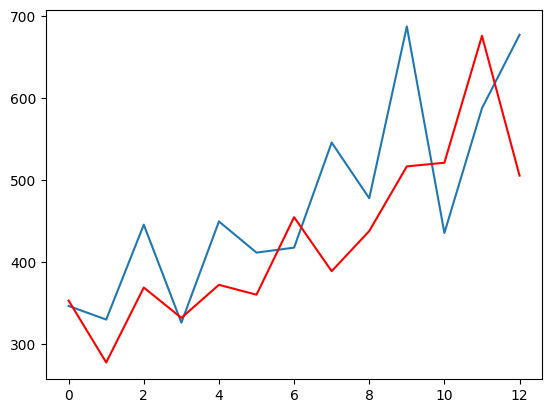

In [11]:
# 코드 7-2 statsmodels 라이브러리를 이용한 sales 데이터셋 예측

import numpy as np
from pandas import read_csv
from pandas import DatetimeIndex
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

!git clone https://github.com/gilbutITbook/080289.git
%cd 080289/chap05/data/catanddog/

df = read_csv('/content/080289/chap07/data/sales.csv', header=0, parse_dates=[0], index_col=0,
                  date_parser=parser)

series = df.iloc[:, 0]

X = series.values
X = np.nan_to_num(X)

size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)
    print('predicted=%f, expected=%f' % (yhat, obs))

error = mean_squared_error(test, predictions)
print('Test MSE: %.3f' % error)  # 모델 실행 결과를 predicted로 출력하고,
                                 # test로 분리해 둔 데이터를 expected로 사용하여 출력

error = mean_squared_error(test, predictions)
print('Test MSE: %.3f' % error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

-> 데이터가 우상향 추세를 나타내고 있으므로 자전거 판매가 향후에도 계속 증가할 것임을 예측할 수 있음.

---
---

# 7.3 순환 신경망(RNN)

**RNN(Recurrent Neural Network)**
- 시간적으로 연속성이 있는 데이터를 처리하려고 고안된 인공 신경망
- RNN의 Recurrent(반복되는)는 이전 은닉층이 현재 은닉층의 입력이 되면서 반복되는 *순환 구조*를 갖는다는 의미.
- RNN이 기존 네트워크와 다른 점은 *기억*(현재까지 입력 데이터를 요약한 정보)을 갖는다는 점
- 새로운 입력이 네트워크로 들어올 때마다 기억은 조금씩 수정되며, 결국 최종적으로 남겨진 기억은 모든 입력 전체를 요약한 정보가 됨.

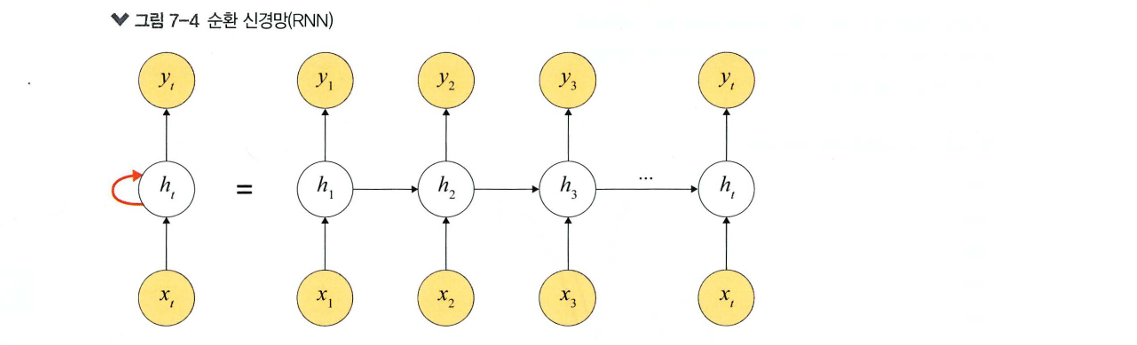

    -> 첫 번째 입력(x1)이 들어오면 첫 번째 기억(h1)이 만들어지고, 두 번째 입력(x2)이 들어오면 기존 기억(h1)과 새로운 입력을 참고하여 새 기억(h2)을 만듦.
        입력 길이만큼 이 과정을 반복.
    -> 즉 RNN은 외부입력과 자신의 이전 상태를 입력받아 현재 상태를 갱신함.

**RNN의 유형**
1. 일대일: 순환이 없기 때문에 RNN이라고 말하기 어려움. \
    ex) 순방향 네트워크

2. 일대다: 입력이 하나이고, 출력이 다수인 구조.\
    ex) 이미지를 입력해서 이미지에 대한 설명을 문장으로 출력하는 이미지 캡션(image cartioning)

3. 다대일: 입력이 다수이고 출력이 하나인 구조.\
    ex) 문장을 입력해서 긍정/부정을 출력히는 감성 분석기

4. 다대다: 입력과 출력이 다수인 구조. \
    ex) 언어를 번역하는 자동 번역기 등

5. 동기화 다대다: 4의 유형처럼 입력과 출력이 다수인 구조.\
    ex) 문장에서 다음에 나올 단어를 예측하는 언어 모델 (프레임 수준의 비디오 분류)

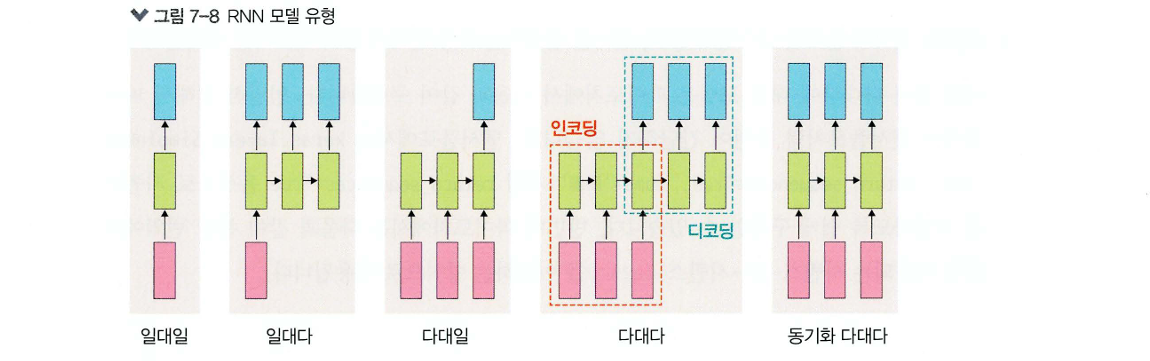

---

**다대일 모델 파이토치에서 구현**

```python
self.em = nn.Emedding(len(TEXT.vocal.stoi), embeding_dim)   # 임베딩 처리
self.rnn = nn.RNNCell(input_dim, hidden_size)               # RNN 적용
self.fc1 = nn.Linear(hidden_size, 256)                      # 완전연결층
self.fc2 = nn.Linear(256, 3)                                # 출력층
```

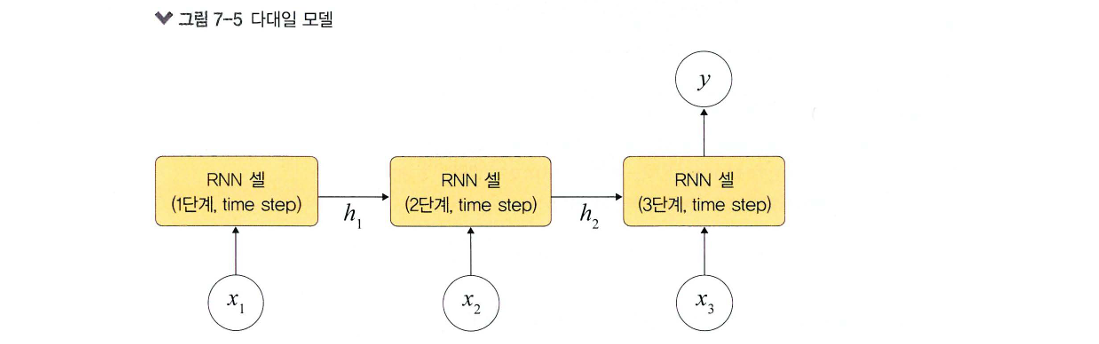

코드는 입력과 출력 사이에 하나의 RNN 셀만 가지고 있음.

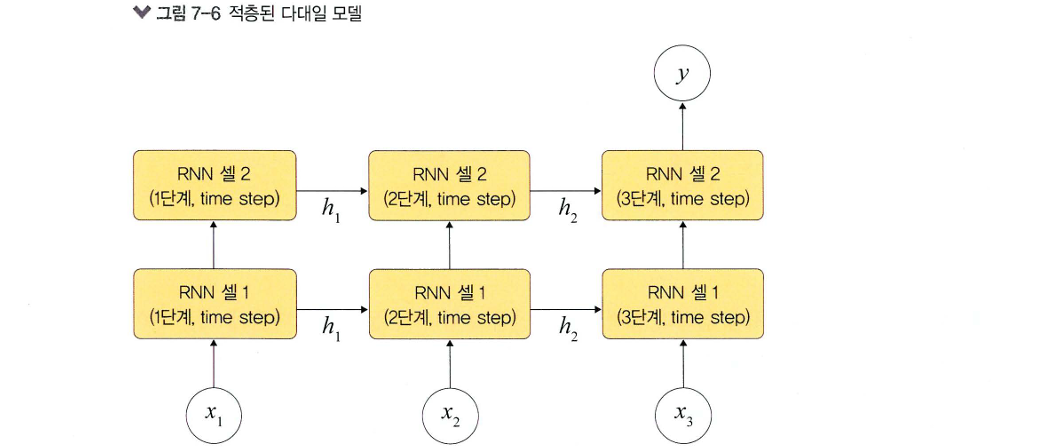

---

**다대다 모델 파이토치에서 구현**
```python
Seq2Seq(
    (encoder): Encoder(
        (embedding): Embedding(7855, 256)
        (rnn): LSTM(256, 512, num_layer=2, dropout=0.5)
        (dropout): Dropout(p=0.5, inplace=False)
    )
    (decoder): Decoder(
        (embedding): Embedding(5893, 256)
        (rnn): LSTM(256, 512, num_layer=2, dropout=0.5)
        (fc_out): LInear(512, out_features=5893, bias=True)
        (dropout): Dropout(p=0.5, inplace=False)
    )
)
```

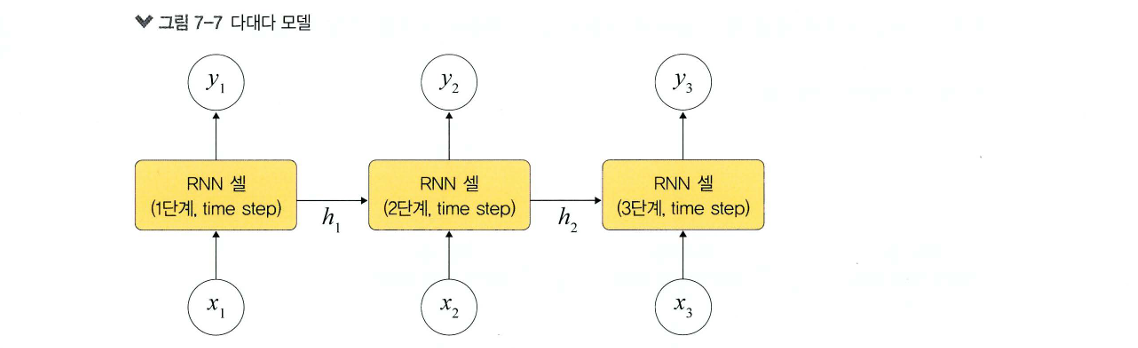

---

## 7.3.1 RNN 계층과 셀

RNN은 내장된(built-in) 계층뿐만 아니라 셀 레벨의 API도 제공함.\
RNN 계층이 입력된 배치 순서대로 모두 처리하는 것과 다르게 RNN 셀은 오직 하나의 단계(time step)만 처리함. \

 -> RNN 셀은 RNN 계층의 for loop 구문을 갖는 구조

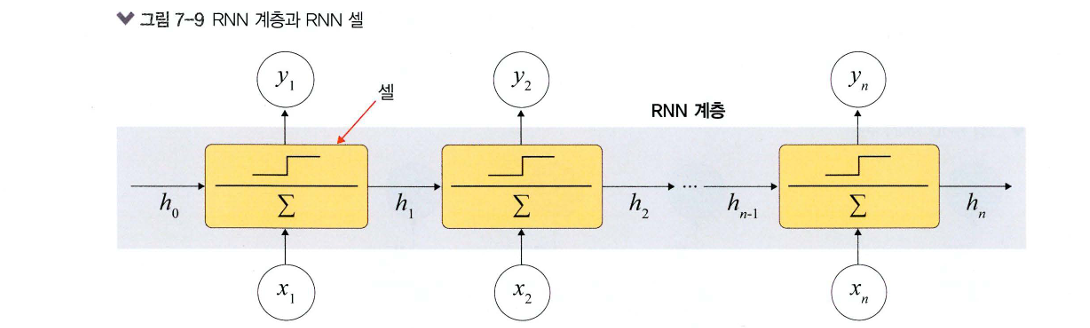

RNN 계층은 셀을 래핑하여 동일한 셀을 여러 단계에 적용함.\
셀은 실제 계산에 사용되는 RNN 계층의 구성 요소로, 단일 입력과 과거 상태를 가져와서 출력과 새로운 상태를 생성함.

**셀 유형**
- nn.RNNCell: SimpleRNN 계층에 대응되는 RNN 셀
- nn.GRUCell: GRU 계층에 대응되는 GRU 셀
- nn.LSTMCell: LSTM 계층에 대응되는 LSTM 셀

**RNN의 활용 분야**
- 자연어(음성 인식, 단어의 의미 판단 및 대화 등) 처리
- 시계열 데이터(손글씨, 센서 데이터 등) 처리